### Блок 3  Анализ сегментов клиентской базы
#### Часть 1

**1.**
Изучение различий между городами.

Рассчет по каждому городу:

+ Средняя выручку на 1 пользователя за месяц
+ Доля индивидуальных тренировок от общего числа занятий
+ Количества уникальных пользователей

Построение scatterplot, где:
+ Ось X — доля индивидуальных тренировок

+ Ось Y — средняя выручка за месяц

+ Цвет — город

Построение пузырьковой диаграммы (bubble plot), где размер пузырька - это количество уникальных пользователей в городе

**2.** 
Изучение ключевых метрик по возрастным группам

Разделение клиентов на три возрастные группы:

+ до 30 лет

+ от 30 до 45 лет

+ старше 45 лет

Для каждой возрастной группы рассчитана:

+ Средняя доля индивидуальных тренировок

+ Среднее количество тренировок в месяц

+ Средняя выручка на 1 пользователя за месяц

+ Общее количество клиентов в группе


**3.** 
Изучение премиального сегмента

+  10 пользователей с самой высокой совокупной выручкой (LTR). Использована сумму всех платежей пользователя за весь период.
+ Вывод для этих пользователей города, пола, средней выручки за месяц, среднее количество тренировок в месяц и количество месяцев, которые они тренировались.

**4.** 
Удержание пользователей после первого месяца тренировок:

+ Создание  когорты для каждого пользователя — определение месяца их первого визита (min_mon).
+ Рассчет индекса когорты (cohort_index), который показывает, какой по счёту месяц после первого визита рассматривается для каждого пользователя.
+ Для каждой когорты и каждого месяца жизни расчет количество уникальных активных пользователей.
+ Построение когортноц таблицы удержания —  какая доля пользователей осталась активной в каждом следующем месяце после первого визита.
+ Визуализация результатов в виде тепловой карты с retention за первые 4 месяца для каждой когорты.

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


### 1. Различия по городам

In [4]:
pay_user = df.groupby(['id_user', 'city']).agg({'mon':'count',
                                               'cnt_indiv':'sum',
                                               'cnt_total':'sum',
                                               'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'})
pay_user.head()

,id_user,city,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,СПб,9,33,33,58600
1,1001,Москва,11,23,129,124800
2,1002,Москва,11,64,128,166000
3,1004,Екатеринбург,9,18,18,32000
4,1005,СПб,2,7,7,12600


In [5]:
pay_user['avg_monthly_revenue'] = pay_user['sum_total']/pay_user['nmonths']

In [6]:
pay_user['share_indiv'] = pay_user['cnt_indiv']/pay_user['cnt_total']

In [7]:
pay_user.head()

,id_user,city,nmonths,cnt_indiv,cnt_total,sum_total,avg_monthly_revenue,share_indiv
0,1000,СПб,9,33,33,58600,6511.111111,1.000000
1,1001,Москва,11,23,129,124800,11345.454545,0.178295
2,1002,Москва,11,64,128,166000,15090.909091,0.500000
3,1004,Екатеринбург,9,18,18,32000,3555.555556,1.000000
4,1005,СПб,2,7,7,12600,6300.000000,1.000000


In [8]:
city_stats = pay_user.groupby('city').agg({'id_user':'nunique',
                                          'avg_monthly_revenue':'mean',
                                          'share_indiv':'mean'}).reset_index().rename(columns = {'id_user':'nusers'})
city_stats

,city,nusers,avg_monthly_revenue,share_indiv
0,Екатеринбург,128,6735.819862,0.308108
1,Казань,127,6698.701412,0.247886
2,Москва,310,7194.958013,0.654638
3,СПб,273,7123.468912,0.333030


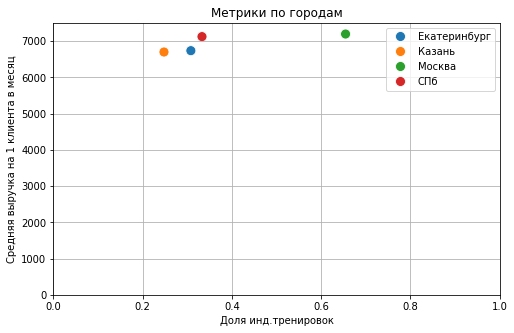

In [9]:
# динамика тренировок
plt.figure(figsize=(8, 5))
plt.xlim(0, 1)
plt.ylim(0, 7500)
sns.scatterplot(data = city_stats,
               x = 'share_indiv',
               y = 'avg_monthly_revenue',
               hue = 'city',
               s = 100)
plt.xlabel('Доля инд.тренировок')
plt.ylabel('Средняя выручка на 1 клиента в месяц')
plt.title('Метрики по городам')
plt.legend()
plt.grid(True)
plt.show()

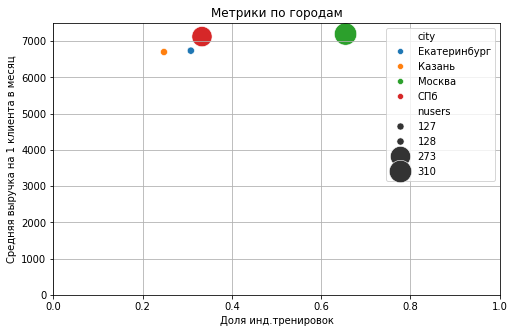

In [10]:
# динамика тренировок
plt.figure(figsize=(8, 5))
plt.xlim(0, 1)
plt.ylim(0, 7500)
sns.scatterplot(data = city_stats,
               x = 'share_indiv',
               y = 'avg_monthly_revenue',
               hue = 'city',
                size='nusers',
                sizes=(50, 500))
plt.xlabel('Доля инд.тренировок')
plt.ylabel('Средняя выручка на 1 клиента в месяц')
plt.title('Метрики по городам')
plt.legend()
plt.grid(True)
plt.show()

### 2. Сравнение по возрастным когортам

In [11]:
def age_group(age):
    if age<=30:
        return '18-30'
    elif (age>=31) and (age<=45):
        return '31-45'
    else:
        return '46+'

In [12]:
df['age_gr'] = df['age'].apply(age_group)
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31-45
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31-45
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female,31-45
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31-45
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31-45


In [13]:
age_user = df.groupby(['id_user', 'age_gr']).agg({'mon':'count',
                                               'cnt_indiv':'sum',
                                               'cnt_total':'sum',
                                               'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'})
age_user.head()

,id_user,age_gr,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,31-45,9,33,33,58600
1,1001,31-45,11,23,129,124800
2,1002,31-45,11,64,128,166000
3,1004,46+,9,18,18,32000
4,1005,31-45,2,7,7,12600


In [14]:
age_user['avg_monthly_revenue'] = age_user['sum_total']/age_user['nmonths']

In [15]:
age_user['share_indiv'] = age_user['cnt_indiv']/age_user['cnt_total']

In [16]:
age_user['avg_train_per_mon'] = age_user['cnt_total']/age_user['nmonths']

In [17]:
age_user.head()

,id_user,age_gr,nmonths,cnt_indiv,cnt_total,sum_total,avg_monthly_revenue,share_indiv,avg_train_per_mon
0,1000,31-45,9,33,33,58600,6511.111111,1.000000,3.666667
1,1001,31-45,11,23,129,124800,11345.454545,0.178295,11.727273
2,1002,31-45,11,64,128,166000,15090.909091,0.500000,11.636364
3,1004,46+,9,18,18,32000,3555.555556,1.000000,2.000000
4,1005,31-45,2,7,7,12600,6300.000000,1.000000,3.500000


In [18]:
age_segm = age_user.groupby('age_gr').agg({'id_user':'nunique',
                                          'nmonths':'mean',
                                          'avg_monthly_revenue':'mean',
                                          'avg_train_per_mon':'mean',
                                          'share_indiv':'mean'}).reset_index().rename(columns = {'id_user': 'nusers'})

age_segm

,age_gr,nusers,nmonths,avg_monthly_revenue,avg_train_per_mon,share_indiv
0,18-30,278,5.399281,8222.747802,7.290366,0.446690
1,31-45,271,5.343173,7774.985357,7.003930,0.445543
2,46+,289,5.681661,5173.422485,4.737098,0.414714


###  3. Топ-10 пользователей по LTR

In [19]:
df_gr = df.groupby('id_user').agg({'sum_total':'sum'}).reset_index().sort_values('sum_total', ascending = False).head(10)
df_gr

,id_user,sum_total
2,1002,166000
551,1657,164200
319,1381,147600
135,1153,147400
420,1506,146400
27,1029,140000
12,1013,139800
485,1582,136200
446,1536,134400
402,1482,131400


In [20]:
user_lst = df_gr['id_user'].tolist()
user_lst

[1002, 1657, 1381, 1153, 1506, 1029, 1013, 1582, 1536, 1482]

In [21]:
df_top = df[df['id_user'].isin(user_lst)]
df_top.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
20,1002,2023-02,4,8,3200,14400,12,17600,2023-02,2023-12,Москва,34.0,male,31-45
21,1002,2023-03,4,8,3200,14400,12,17600,2023-02,2023-12,Москва,34.0,male,31-45
22,1002,2023-04,7,4,5600,7200,11,12800,2023-02,2023-12,Москва,34.0,male,31-45
23,1002,2023-05,2,10,1600,16000,12,17600,2023-02,2023-12,Москва,34.0,male,31-45
24,1002,2023-06,7,4,5600,7200,11,12800,2023-02,2023-12,Москва,34.0,male,31-45


In [22]:
user_top = df_top.groupby(['id_user', 'city', 'gender', 'age_gr']).agg({'mon':'count',
                                                                       'cnt_total':'sum',
                                                                       'sum_total':'sum'}).reset_index().rename(columns = \
                                                                                                    {'mon':'nmonths'})

In [23]:
user_top

,id_user,city,gender,age_gr,nmonths,cnt_total,sum_total
0,1002,Москва,male,31-45,11,128,166000
1,1013,Москва,male,31-45,11,151,139800
2,1029,СПб,female,31-45,8,126,140000
3,1153,СПб,male,46+,12,118,147400
4,1381,Москва,female,18-30,12,159,147600
5,1482,Москва,female,18-30,11,110,131400
6,1506,Москва,female,18-30,10,138,146400
7,1536,Москва,female,18-30,9,125,134400
8,1582,Екатеринбург,male,31-45,8,127,136200
9,1657,СПб,male,18-30,10,144,164200


In [24]:
user_top['avg_monthly_revenue'] = user_top['sum_total']/user_top['nmonths']

In [25]:
user_top['avg_train_per_mon'] = user_top['cnt_total']/user_top['nmonths']

In [26]:
user_top

,id_user,city,gender,age_gr,nmonths,cnt_total,sum_total,avg_monthly_revenue,avg_train_per_mon
0,1002,Москва,male,31-45,11,128,166000,15090.909091,11.636364
1,1013,Москва,male,31-45,11,151,139800,12709.090909,13.727273
2,1029,СПб,female,31-45,8,126,140000,17500.000000,15.750000
3,1153,СПб,male,46+,12,118,147400,12283.333333,9.833333
4,1381,Москва,female,18-30,12,159,147600,12300.000000,13.250000
5,1482,Москва,female,18-30,11,110,131400,11945.454545,10.000000
6,1506,Москва,female,18-30,10,138,146400,14640.000000,13.800000
7,1536,Москва,female,18-30,9,125,134400,14933.333333,13.888889
8,1582,Екатеринбург,male,31-45,8,127,136200,17025.000000,15.875000
9,1657,СПб,male,18-30,10,144,164200,16420.000000,14.400000


In [27]:
user_top['city'].value_counts()

city
Москва          6
СПб             3
Екатеринбург    1
Name: count, dtype: int64

In [28]:
user_top['gender'].value_counts()

gender
male      5
female    5
Name: count, dtype: int64

In [29]:
user_top['age_gr'].value_counts()

age_gr
18-30    5
31-45    4
46+      1
Name: count, dtype: int64

### 4. Анализ доходимости когорт

In [30]:
df['mon'] = pd.to_datetime(df['mon'], format = "%Y-%m")

In [31]:
df['min_mon'] = pd.to_datetime(df['min_mon'], format = "%Y-%m")

In [32]:
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
0,1000,2023-03-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45
1,1000,2023-04-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45
2,1000,2023-05-01,0,4,0,6400,4,6400,2023-03-01,2023-12,СПб,44.0,female,31-45
3,1000,2023-06-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45
4,1000,2023-07-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45


In [33]:
df['cohort_index'] = df['mon'].dt.month - df['min_mon'].dt.month 
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr,cohort_index
0,1000,2023-03-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45,0
1,1000,2023-04-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45,1
2,1000,2023-05-01,0,4,0,6400,4,6400,2023-03-01,2023-12,СПб,44.0,female,31-45,2
3,1000,2023-06-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45,3
4,1000,2023-07-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45,4


In [34]:
cohort_stats = df.groupby(['min_mon','cohort_index']).agg(active_users = ('id_user', 'nunique')).reset_index()
cohort_stats.head()

,min_mon,cohort_index,active_users
0,2023-01-01,0,337
1,2023-01-01,1,262
2,2023-01-01,2,205
3,2023-01-01,3,168
4,2023-01-01,4,159


In [35]:
cohort_size = cohort_stats[cohort_stats['cohort_index']==0][['min_mon', 'active_users']].rename(columns =\
                                                                                    {'active_users':'cohsize'})

In [36]:
cohort_data = cohort_stats.merge(cohort_size, on = 'min_mon')
cohort_data.head()

,min_mon,cohort_index,active_users,cohsize
0,2023-01-01,0,337,337
1,2023-01-01,1,262,337
2,2023-01-01,2,205,337
3,2023-01-01,3,168,337
4,2023-01-01,4,159,337


In [37]:
cohort_data['retention'] = cohort_data['active_users']/cohort_data['cohsize']
cohort_data.head()

,min_mon,cohort_index,active_users,cohsize,retention
0,2023-01-01,0,337,337,1.000000
1,2023-01-01,1,262,337,0.777448
2,2023-01-01,2,205,337,0.608309
3,2023-01-01,3,168,337,0.498516
4,2023-01-01,4,159,337,0.471810


In [38]:
retention_table = pd.pivot_table(cohort_data, index = 'min_mon', columns = 'cohort_index', values = 'retention')

In [39]:
retention_table.index = retention_table.index.strftime('%Y-%m')

In [40]:
retention_table.iloc[:, :4]

cohort_index,0,1,2,3
min_mon,,,,
2023-01,1.0,0.777448,0.608309,0.498516
2023-02,1.0,0.761364,0.602273,0.568182
2023-03,1.0,0.746988,0.590361,0.578313
2023-04,1.0,0.725806,0.645161,0.548387
2023-05,1.0,0.701754,0.561404,0.614035
2023-06,1.0,0.823529,0.705882,0.549020
2023-07,1.0,0.770833,0.666667,0.666667
2023-08,1.0,0.885714,0.571429,0.400000
2023-09,1.0,0.678571,0.500000,0.464286


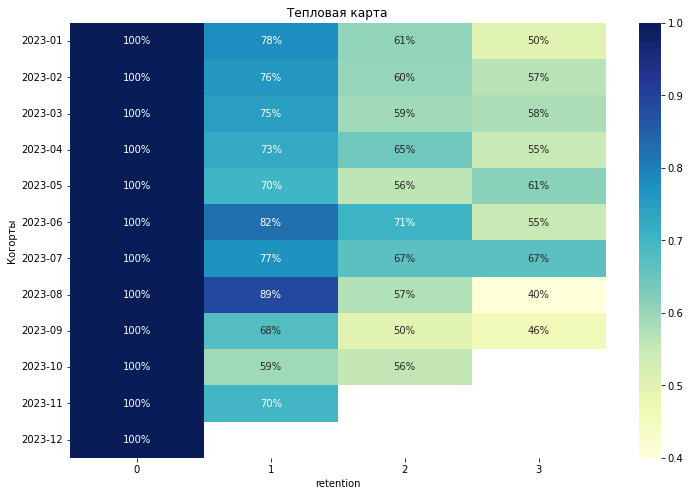

In [41]:
plt.figure(figsize=(12, 8))
sns.heatmap(retention_table.iloc[:, :4], annot = True, fmt = ".0%", cmap = 'YlGnBu')
plt.xlabel('retention')
plt.ylabel('Когорты')
plt.title('Тепловая карта')
plt.show()

## Часть 2. Факторный анализ премиального сегмента: Портрет высокодоходного клиента

### Пользователи, которые делают упор на индивидуальные тренировки

In [11]:
df = pd.read_csv('merged_data.csv')
df.head(3)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female


In [12]:
user_stats = df.groupby(['id_user', 'city', 'gender']).agg({
    'mon': 'nunique',
    'cnt_indiv': 'sum',
    'cnt_total': 'sum',
    'sum_total':'sum'
}).reset_index().rename(columns = {'mon':'nmonths'})

In [8]:
user_stats['share_indiv'] = user_stats['cnt_indiv'] / user_stats['cnt_total']
indiv_users = user_stats[user_stats['share_indiv'] > 0.7].copy()

In [14]:
df_res = indiv_users.groupby(['city', 'gender']).agg({
    'id_user': 'count',       # Считаем количество VIP-клиентов
    'sum_total': 'mean',      # Считаем их среднюю совокупную выручку
    'cnt_total': 'mean'       # Считаем их среднее общее количество тренировок
}).reset_index().rename(columns={'id_user': 'nusers'})

df_res

,city,gender,nusers,sum_total,cnt_total
0,Екатеринбург,female,12,25616.666667,14.333333
1,Екатеринбург,male,12,27366.666667,15.333333
2,Казань,female,8,18000.000000,10.875000
3,Казань,male,12,24633.333333,13.833333
4,Москва,female,118,22400.000000,12.627119
5,Москва,male,59,25881.355932,14.542373
6,СПб,female,32,28162.500000,15.750000
7,СПб,male,28,18657.142857,10.500000


###  Топ-10 клиентов с наибольшим общим количеством посещений

In [15]:
df_top=df.groupby('id_user').agg(cnt_tot=('cnt_total', 'sum')).reset_index().sort_values('cnt_tot', ascending=False).head(10)
df_top

,id_user,cnt_tot
319,1381,159
12,1013,151
551,1657,144
420,1506,138
780,1929,130
1,1001,129
474,1570,129
2,1002,128
485,1582,127
168,1194,127


In [16]:
top_list=df_top['id_user'].tolist()
top_list

[1381, 1013, 1657, 1506, 1929, 1001, 1570, 1002, 1582, 1194]

In [17]:
dft_sort=df[df['id_user'].isin(top_list)]
dft_sort.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female
10,1001,2023-02,11,3,8800,5400,14,14200,2023-01,2023-12,Москва,35.0,female
11,1001,2023-03,8,6,6400,10800,14,17200,2023-01,2023-12,Москва,35.0,female
12,1001,2023-04,9,5,7200,9000,14,16200,2023-01,2023-12,Москва,35.0,female
13,1001,2023-05,3,7,2400,11200,10,13600,2023-01,2023-12,Москва,35.0,female


In [18]:
user_top= dft_sort.groupby(['city', 'gender'])['id_user'].nunique().reset_index()
user_top.head()

,city,gender,id_user
0,Екатеринбург,male,2
1,Москва,female,3
2,Москва,male,3
3,СПб,female,1
4,СПб,male,1


### Динамика клиентской базы по месяцам (сколько клиентов приходило, сколько уходило и сколько оставалось активными)

In [19]:
# Активные клиенты
active = df.groupby('mon').agg(active_clients=('id_user', 'nunique')).reset_index()
active.head()

,mon,active_clients
0,2023-01,337
1,2023-02,350
2,2023-03,355
3,2023-04,345
4,2023-05,360


In [20]:
#Новые клиенты
new=df[df['mon'] == df['min_mon']].groupby('mon').agg(new_clients=('id_user', 'nunique')).reset_index()
new.head()

,mon,new_clients
0,2023-01,337
1,2023-02,88
2,2023-03,83
3,2023-04,62
4,2023-05,57


In [24]:
# ушедшие клиенты
gone=df[df['mon'] == df['max_mon']].groupby('mon').agg(gone_clients=('id_user', 'nunique')).reset_index()
gone.head()

,mon,gone_clients
0,2023-01,15
1,2023-02,22
2,2023-03,37
3,2023-04,21
4,2023-05,21


In [22]:
res = pd.merge(active, new, on='mon', how='left')
res=pd.merge(res,gone, on='mon', how='left')
res

,mon,active_clients,new_clients,gone_clients
0,2023-01,337,337,15
1,2023-02,350,88,22
2,2023-03,355,83,37
3,2023-04,345,62,21
4,2023-05,360,57,21
5,2023-06,383,51,13
6,2023-07,412,48,33
7,2023-08,423,35,33
8,2023-09,429,28,55
9,2023-10,441,27,101


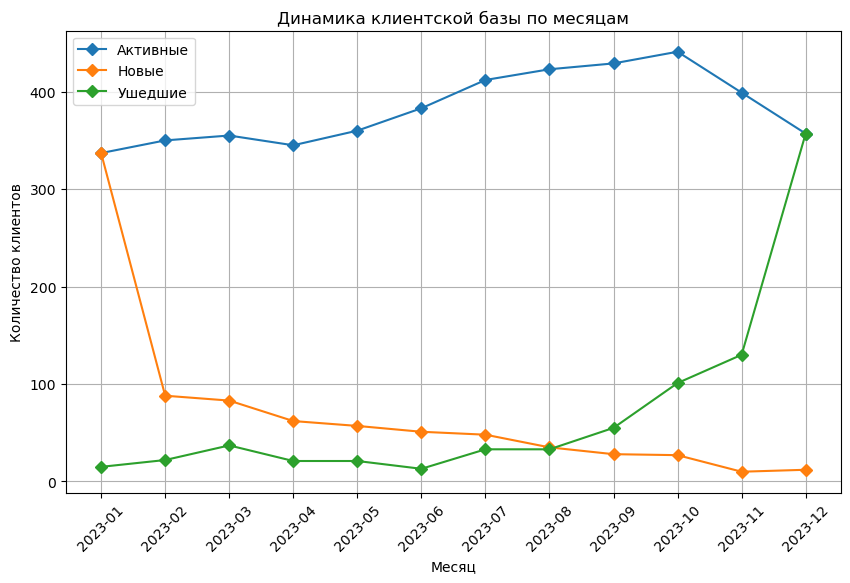

In [23]:
#График

plt.figure(figsize=(10, 6))
plt.plot(res['mon'], res['active_clients'], label='Активные', marker='D')
plt.plot(res['mon'], res['new_clients'], label='Новые',marker='D')
plt.plot(res['mon'], res['gone_clients'], label='Ушедшие', marker='D')

plt.title('Динамика клиентской базы по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество клиентов')
plt.legend() 
plt.grid(True) 
plt.xticks(rotation=45) 

plt.show()